# HD, RF and EBC direction comparisons

Each pair uses shared `(probe, unit_id)` keys, explicit `sorted_by` / `apply_to` heatmaps, and the same circular and pair-distance tests.

HD and EBC angle columns are converted once with `(-angle + 180) % 360 - 180`; RF keeps its signed x coordinates. Sorting, plots, and direction statistics all use these same −180° to 180° coordinates. Peak ties follow the original source-bin order.


In [1]:
%matplotlib inline
from functools import partial
from pathlib import Path
import pandas as pd
from Utils.direction_comparison import (
    ego_coordinates, gen_overlap_list, peak_angles,
    sorted_by_peak, plot_profiles, plot_comparison_heatmaps as compare_heatmaps,
    load_rf_profiles, load_hd_profiles, load_ebc_profiles,
)
from Utils.plotting import apply_light_plot_style, plot_direction_comparison
from Utils.statistic_utils import compare_direction_angles
apply_light_plot_style()


In [2]:
base_dir = Path("/mnt/senzailab/Kai/#Recording/m19")
date = 260827
hd_session_id = 9
rf_session_id = 2
ebc_session_id = 12
ebc_phase = "baseline"
probes = ("A",)

hd_bin_count = 30
hd_smoothing_deg = 3.0
rf_smoothing_bins = 1.5
rf_response_window_s = (0.0, 0.2)
rf_detection_permutations = 10_000
rf_detection_seed = 0
density_bin_count = 12
statistics_permutations = 10_000
statistics_seed = 1


session_dir = base_dir / str(date)
hd_session = session_dir / f"{date}_{hd_session_id}"
rf_session = session_dir / f"{date}_{rf_session_id}"
ebc_session = session_dir / f"{date}_{ebc_session_id}"


## Load profiles

RF uses permutation-significant units; HD uses exact class 2. EBC uses active saved 8–16 cm profiles. Unit lists are saved beside their source files.


In [3]:
rf_profiles = pd.concat([
    load_rf_profiles(
        rf_session, probe=probe, window=rf_response_window_s,
        permutations=rf_detection_permutations, seed=rf_detection_seed,
        smoothing_bins=rf_smoothing_bins,
    )[0]
    for probe in probes
])
rf_unit_ids = rf_profiles.index.get_level_values("unit_id").to_numpy()
rf_unit_ids


array([ 75, 124, 134, 135, 136, 146, 147, 170, 178, 233, 243, 247, 254,
       261, 263, 267, 370])

In [4]:
hd_profiles = pd.concat([
    load_hd_profiles(hd_session / "data/tuning_curves" / f"Probe{probe}" / "tuning_curves.tc",
                     probe=probe, bins=hd_bin_count, smoothing_deg=hd_smoothing_deg)
    for probe in probes
])
hd_unit_ids = hd_profiles.index.get_level_values("unit_id").to_numpy()
hd_unit_ids


array([  6,   7,   9,  19,  24,  26,  27,  39,  43,  47,  50,  59,  60,
        64,  75,  82,  86, 104, 105, 111, 112, 116, 124, 128, 130, 134,
       135, 136, 140, 146, 147, 149, 154, 157, 159, 161, 166, 170, 178,
       186, 189, 200, 206, 209, 215, 220, 224, 226, 229, 233, 243, 245,
       247, 249, 254, 257, 261, 263, 264, 267, 270, 275, 280, 281, 292,
       301, 307, 314, 324, 325, 354, 364, 370, 397, 401, 417, 424, 439])

In [5]:
ebc_profiles = pd.concat([
    load_ebc_profiles(ebc_session / "data/spatial_cells" / f"Probe{probe}" / ebc_phase
                      / "egocentric_rate_map_8-16.rfmap", probe=probe)
    for probe in probes
])
ebc_unit_ids = ebc_profiles.index.get_level_values("unit_id").to_numpy()
ebc_unit_ids


array([  5,   9,  24,  27,  40,  75,  86, 104, 111, 116, 117, 123, 124,
       134, 135, 136, 146, 147, 149, 154, 159, 161, 169, 170, 177, 178,
       182, 185, 191, 201, 202, 232, 233, 236, 241, 243, 247, 249, 254,
       261, 263, 266, 267, 275, 278, 285, 292, 301, 324, 325, 329, 331,
       333, 337, 355, 372, 375, 395, 396, 411])

In [6]:
profile_by_type = {"HD": hd_profiles, "RF": rf_profiles, "EBC": ebc_profiles}
plot_comparison_heatmaps = partial(compare_heatmaps, profile_by_type)

def shared_unit_keys(first, second):
    return gen_overlap_list(profile_by_type[first].index, profile_by_type[second].index)

def analyze_pair(first, second):
    units = shared_unit_keys(first, second)
    reference = peak_angles(profile_by_type[first], units)
    matched = peak_angles(profile_by_type[second], units)
    statistics = compare_direction_angles(
        reference, matched, n_permutations=statistics_permutations, random_seed=statistics_seed,
    )
    plot_direction_comparison(
        reference, matched,
        statistics, reference_label=first, matched_label=second, angle_ticks=ego_coordinates["ticks"],
        reference_ticklabels=ego_coordinates["ticklabels"],
        matched_ticklabels=ego_coordinates["ticklabels"], density_bin_count=density_bin_count,
    )
    return statistics

{"units": {name: len(table) for name, table in profile_by_type.items()},
 "shared_units": {f"{a}-{b}": len(shared_unit_keys(a,b)) for a,b in (("HD","RF"),("HD","EBC"),("RF","EBC"))}}


{'units': {'HD': 78, 'RF': 17, 'EBC': 60},
 'shared_units': {'HD-RF': 17, 'HD-EBC': 33, 'RF-EBC': 16}}

## All profiles, sorted by their own peaks

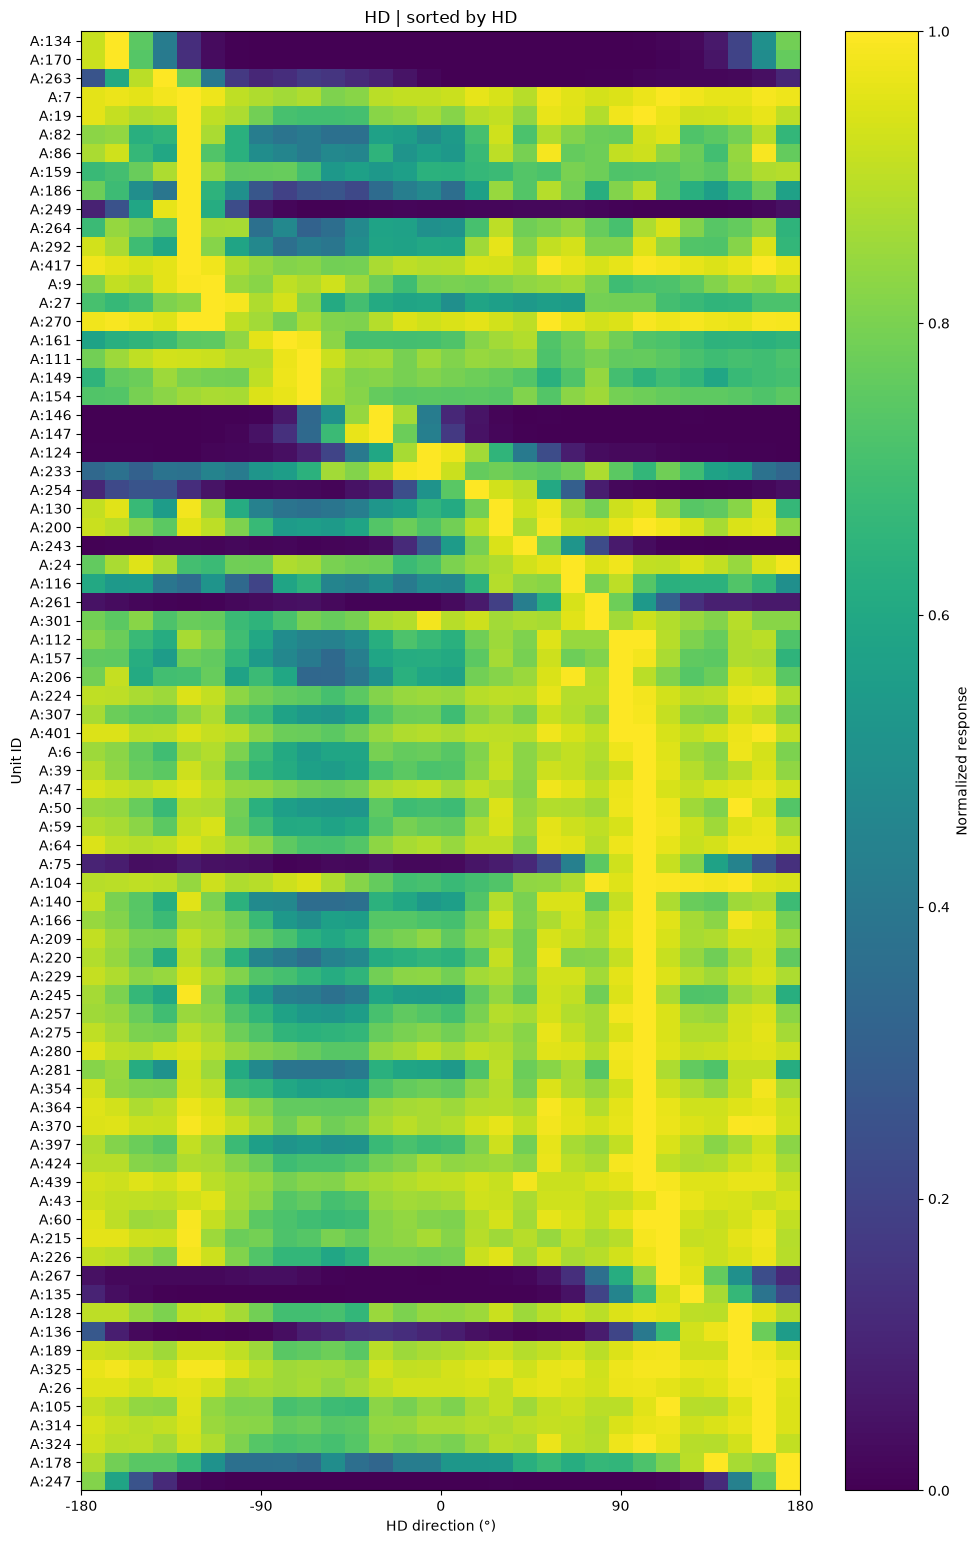

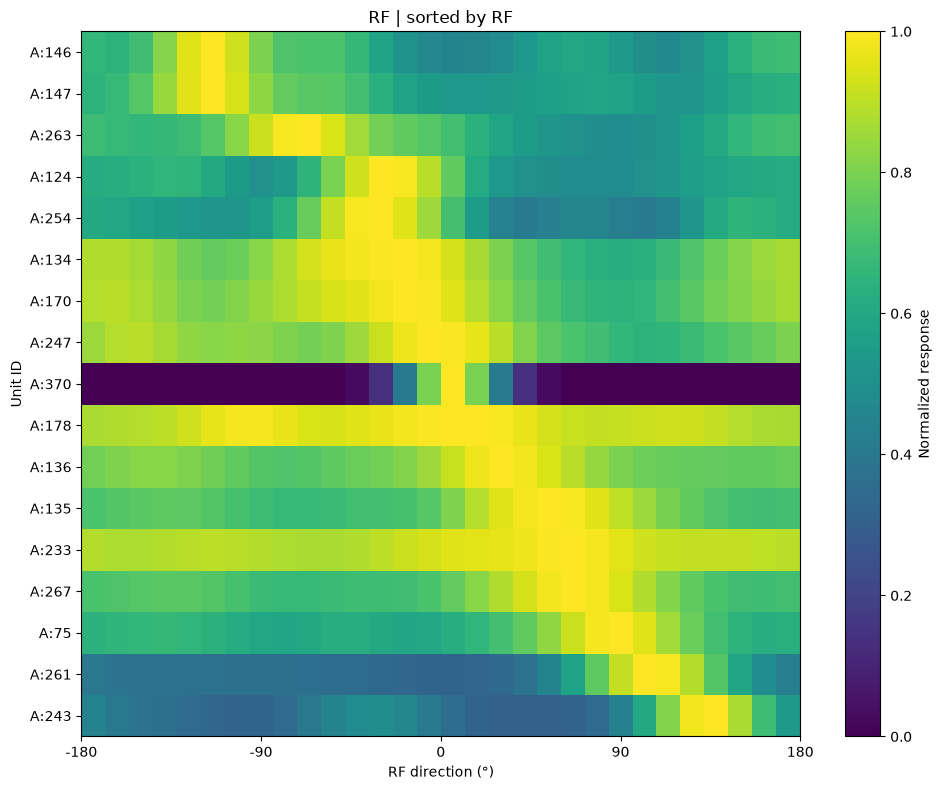

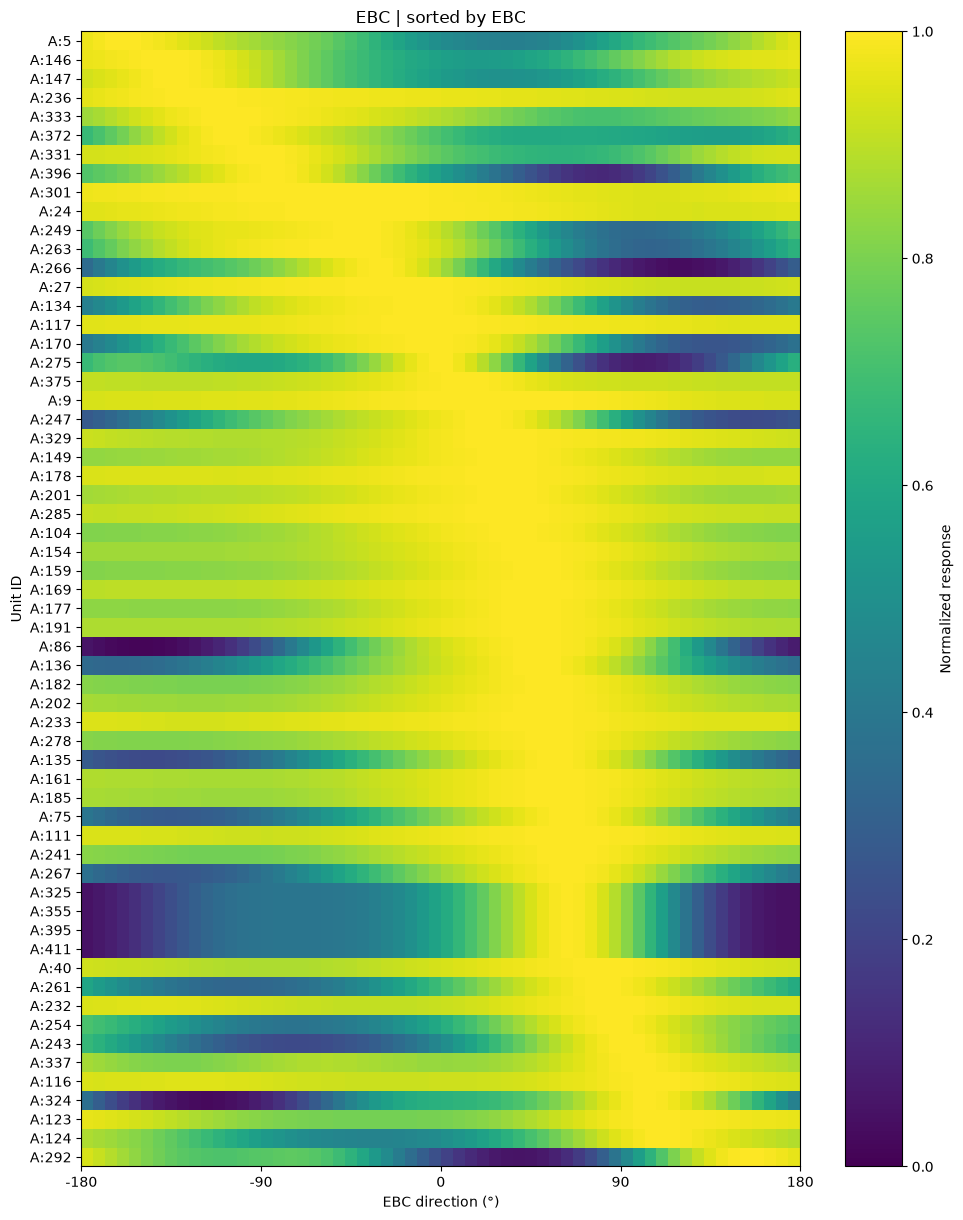

In [7]:
for name, profiles in profile_by_type.items():
    order = sorted_by_peak(profiles, profiles.index)
    plot_profiles(profiles, order, name)


## HD–RF

Each call plots sorted_by and apply_to with the same shared-unit rows, sorted by the sorted_by peak. The two calls explicitly show both sorting directions (four heatmaps). Statistics use HD on x and RF on y.


----- Based on HD -----


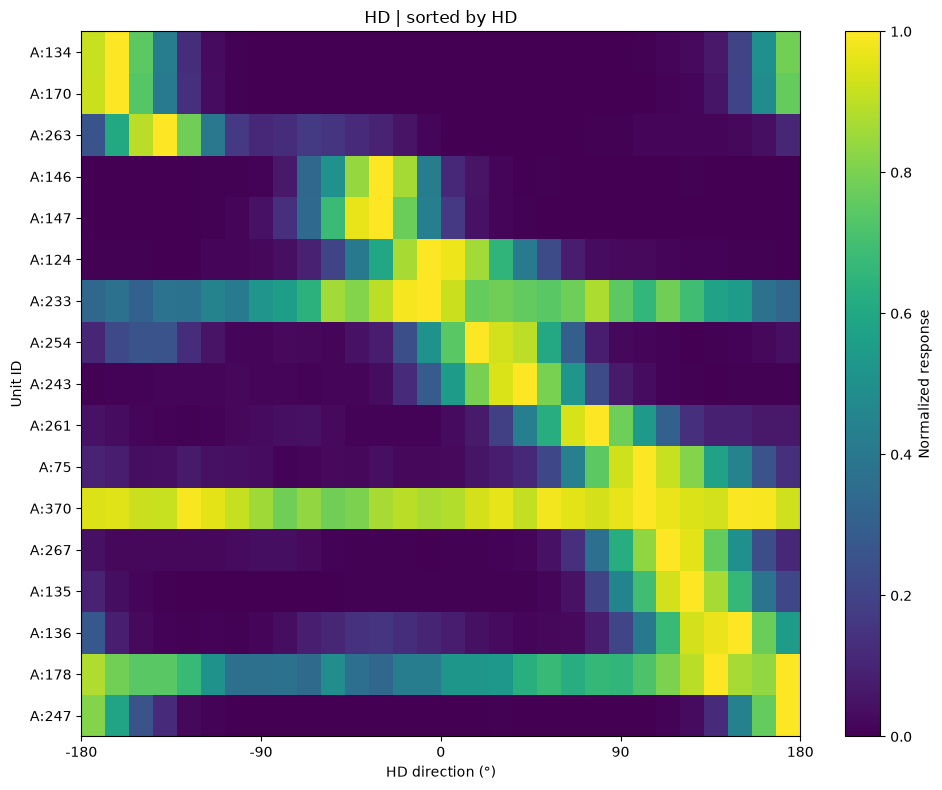

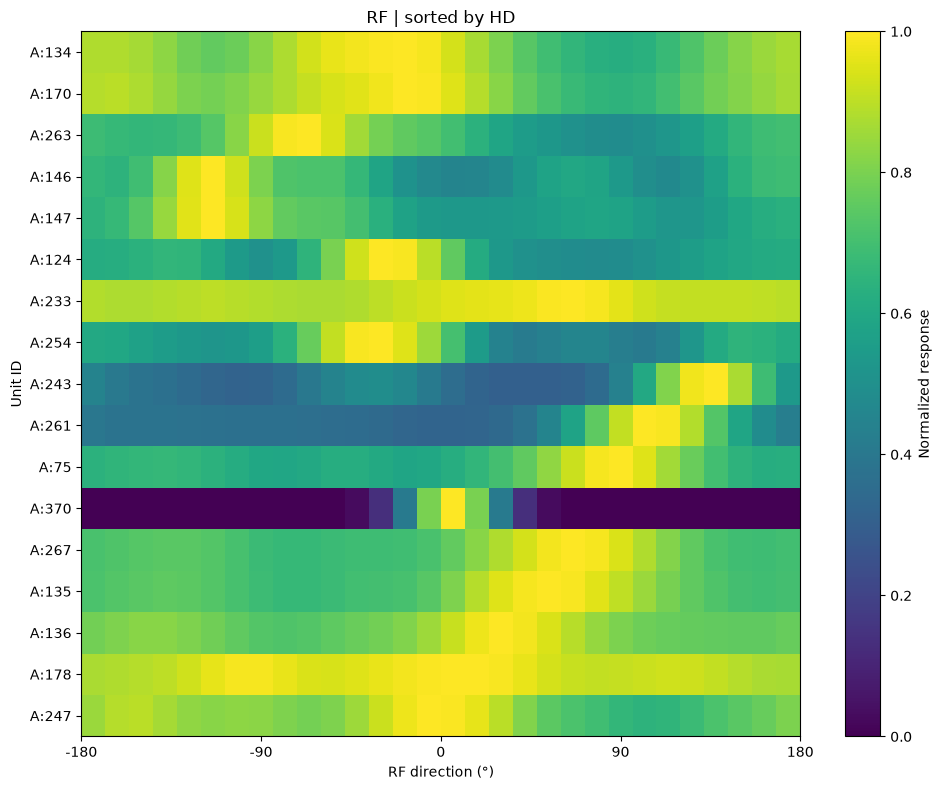

----- Based on RF -----


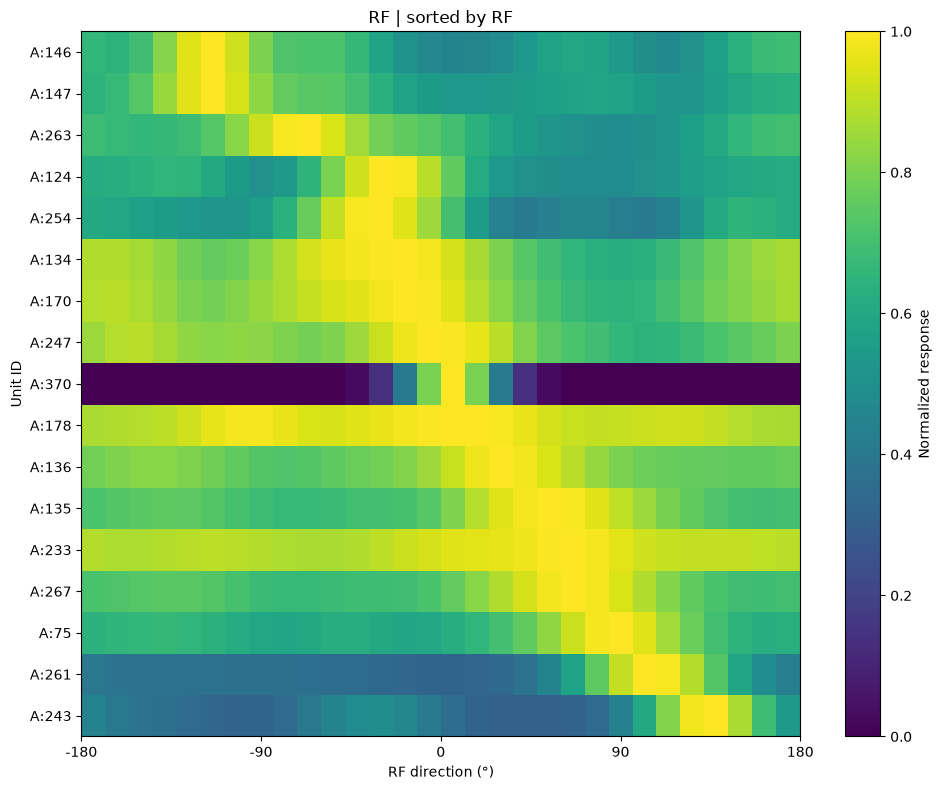

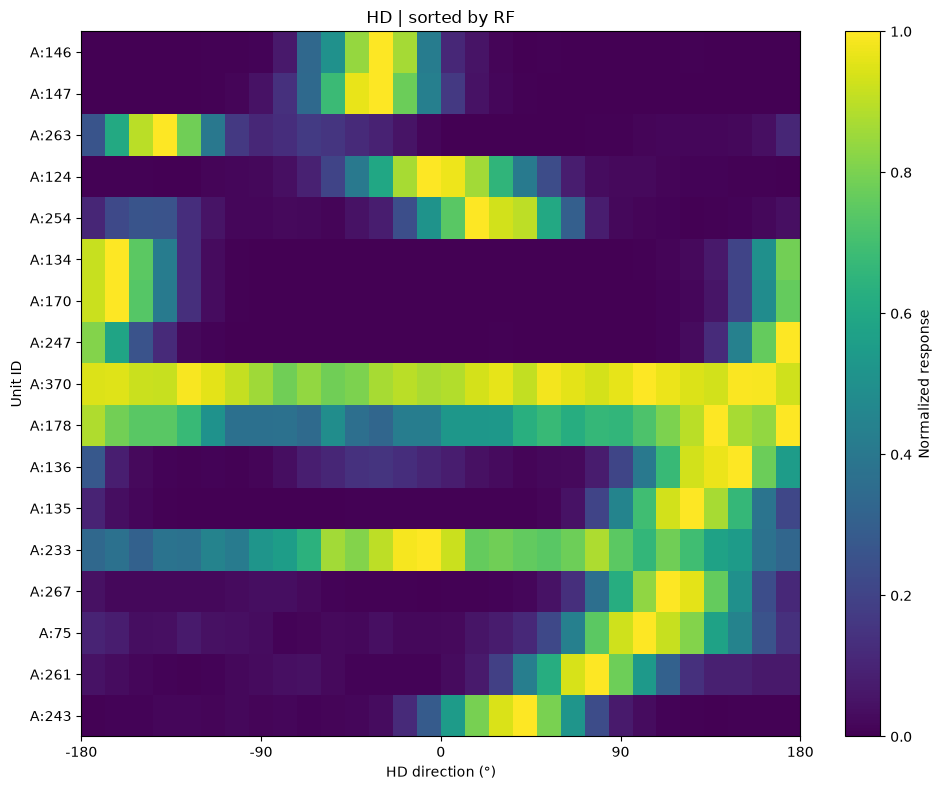

{'order': [('A', 146),
  ('A', 147),
  ('A', 263),
  ('A', 124),
  ('A', 254),
  ('A', 134),
  ('A', 170),
  ('A', 247),
  ('A', 370),
  ('A', 178),
  ('A', 136),
  ('A', 135),
  ('A', 233),
  ('A', 267),
  ('A', 75),
  ('A', 261),
  ('A', 243)],
 'reference_peak_deg': array([-114., -114.,  -66.,  -30.,  -30.,  -18.,  -18.,   -6.,    6.,
          18.,   30.,   54.,   66.,   66.,   90.,  102.,  138.]),
 'offset_deg': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'figures': [(<Figure size 1000x800 with 2 Axes>,
   <Axes: title={'center': 'RF | sorted by RF'}, xlabel='RF direction (°)', ylabel='Unit ID'>),
  (<Figure size 1000x800 with 2 Axes>,
   <Axes: title={'center': 'HD | sorted by RF'}, xlabel='HD direction (°)', ylabel='Unit ID'>)]}

In [8]:
print("----- Based on HD -----")
plot_comparison_heatmaps(sorted_by="HD", apply_to="RF")
print("----- Based on RF -----")
plot_comparison_heatmaps(sorted_by="RF", apply_to="HD")


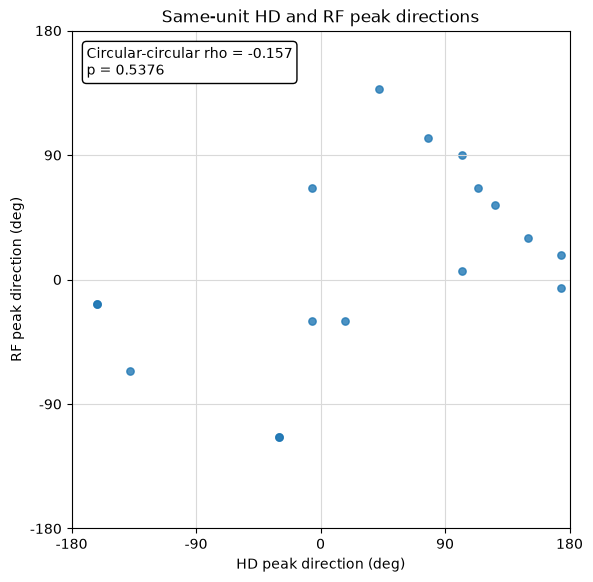

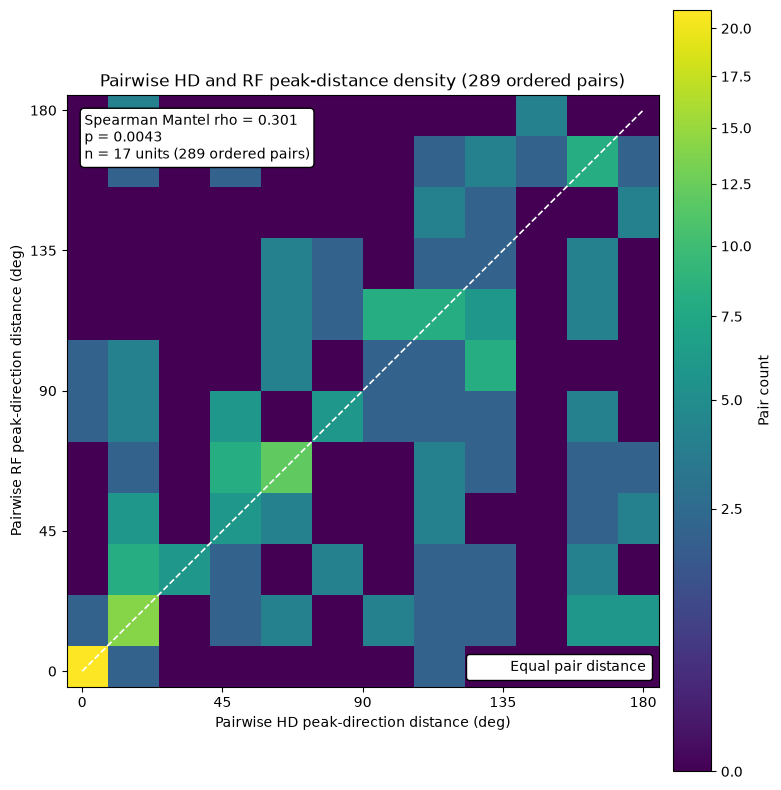

{'same_unit': {'circular_correlation_rho': -0.15702575297816043,
  'permutation_p': 0.5376462353764624,
  'one_to_one_offset_deg': -69.83635678498264,
  'alignment_resultant': 0.17730053241569566,
  'unit_count': 17},
 'pairwise': {'spearman_mantel_rho': 0.30117279602190167,
  'permutation_p': 0.004299570042995701,
  'unit_count': 17,
  'ordered_pair_count': 289}}

In [9]:
hd_rf_statistics = analyze_pair("HD", "RF")
hd_rf_statistics

## HD–EBC



----- Based on HD -----


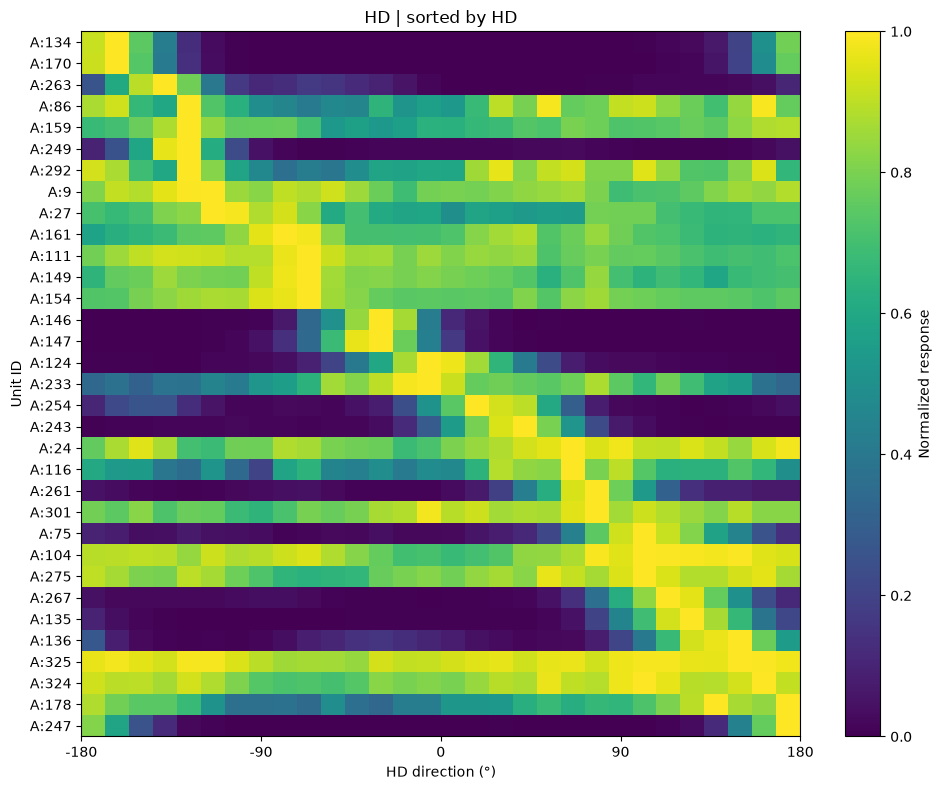

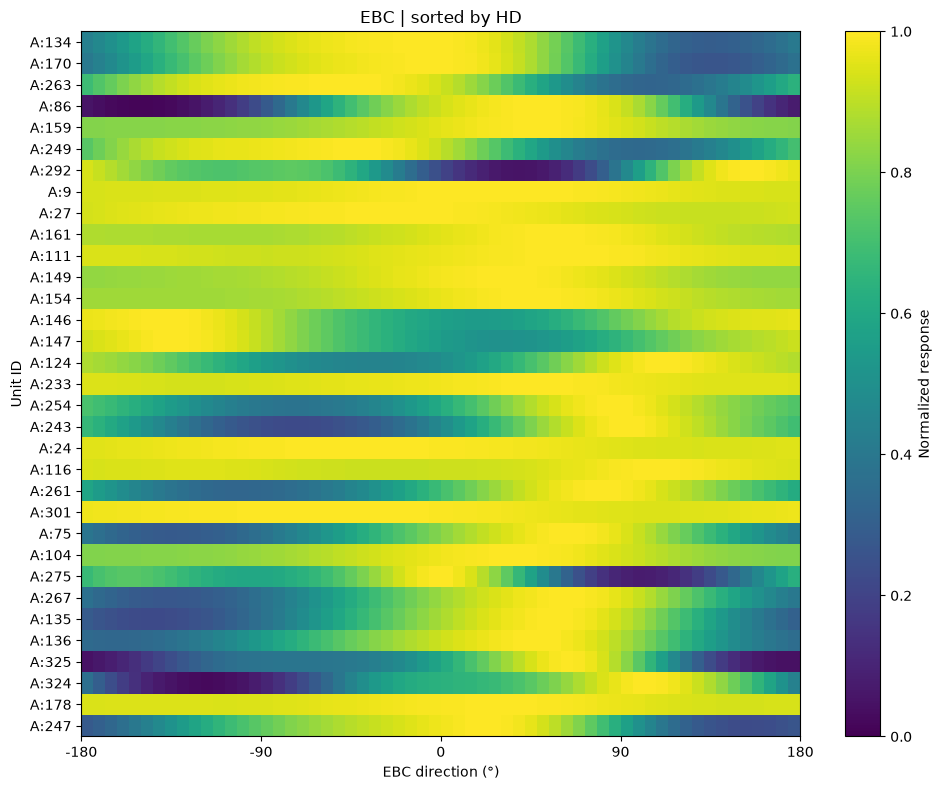

----- Based on EBC -----


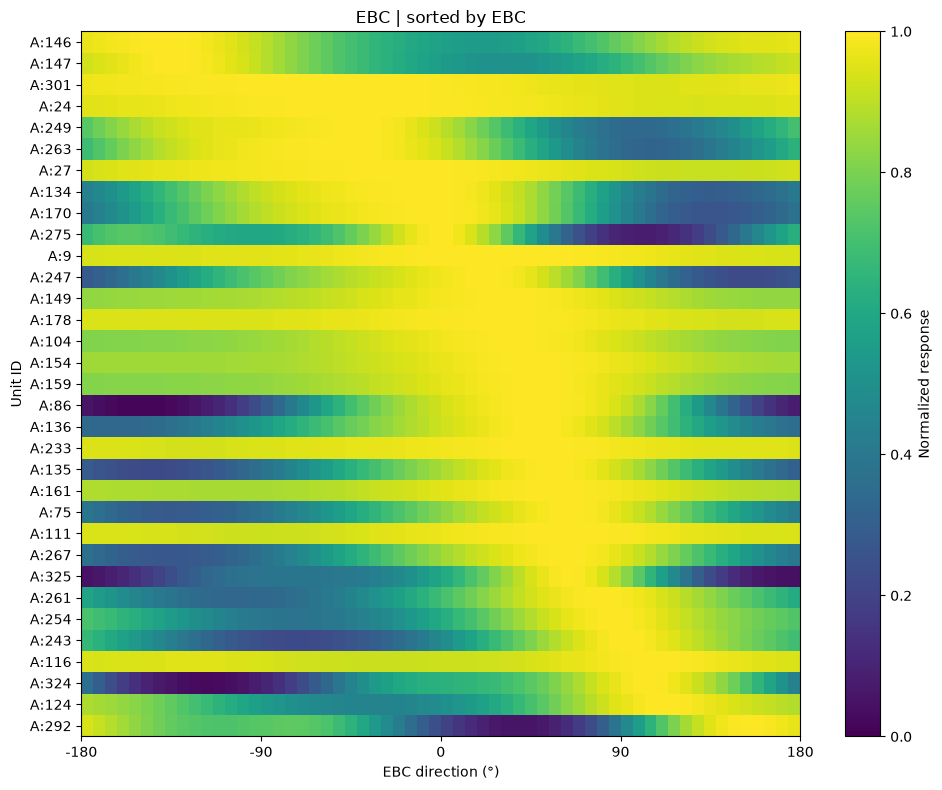

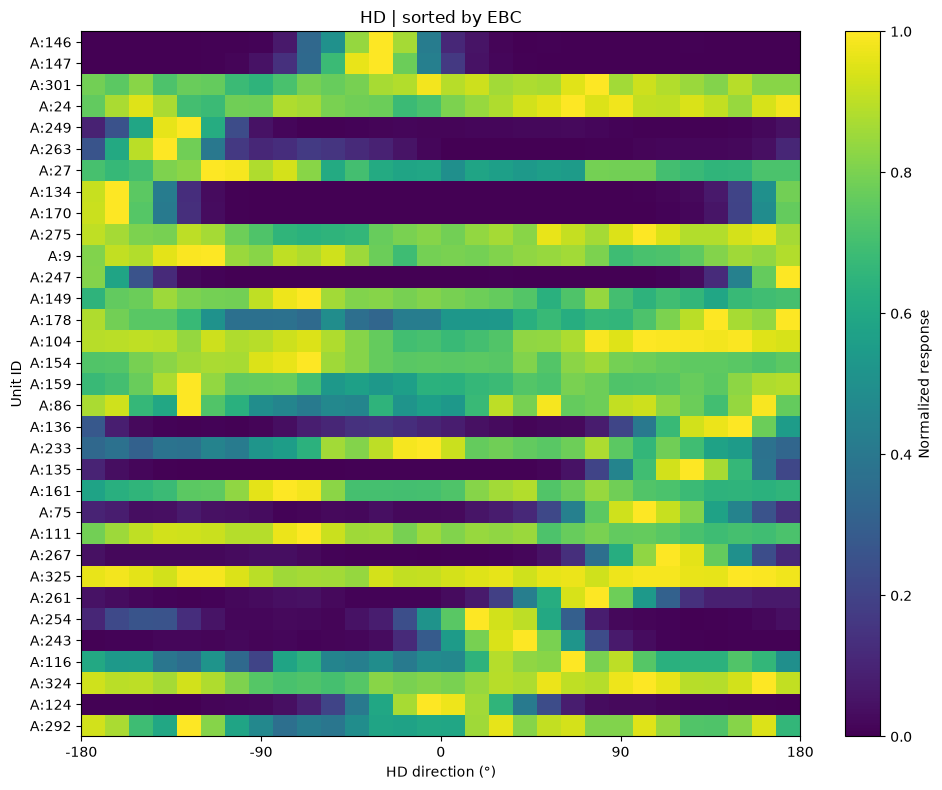

{'order': [('A', 146),
  ('A', 147),
  ('A', 301),
  ('A', 24),
  ('A', 249),
  ('A', 263),
  ('A', 27),
  ('A', 134),
  ('A', 170),
  ('A', 275),
  ('A', 9),
  ('A', 247),
  ('A', 149),
  ('A', 178),
  ('A', 104),
  ('A', 154),
  ('A', 159),
  ('A', 86),
  ('A', 136),
  ('A', 233),
  ('A', 135),
  ('A', 161),
  ('A', 75),
  ('A', 111),
  ('A', 267),
  ('A', 325),
  ('A', 261),
  ('A', 254),
  ('A', 243),
  ('A', 116),
  ('A', 324),
  ('A', 124),
  ('A', 292)],
 'reference_peak_deg': array([-135., -135.,  -51.,  -45.,  -45.,  -45.,  -21.,   -9.,   -3.,
          -3.,   21.,   21.,   33.,   33.,   39.,   45.,   45.,   51.,
          51.,   51.,   57.,   57.,   63.,   63.,   63.,   63.,   81.,
          87.,   93.,  105.,  105.,  111.,  153.]),
 'offset_deg': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'figures': [(<Figure size 1000x800 with 2 Axes>,
   <Axes: title={'center': 'EBC |

In [10]:
print("----- Based on HD -----")
plot_comparison_heatmaps(sorted_by="HD", apply_to="EBC")
print("----- Based on EBC -----")
plot_comparison_heatmaps(sorted_by="EBC", apply_to="HD")


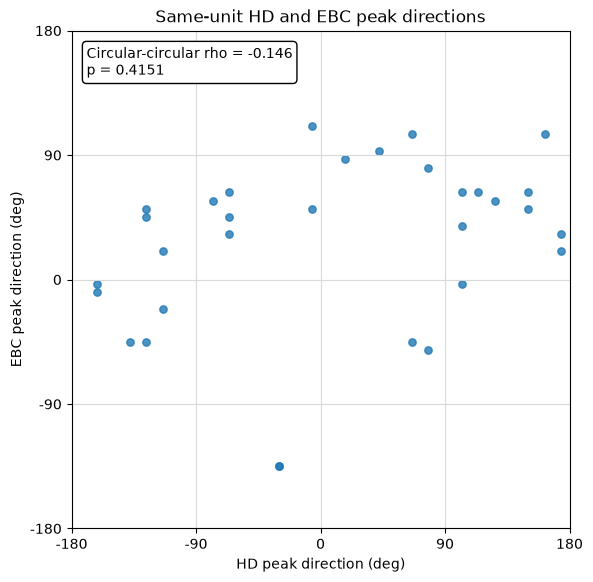

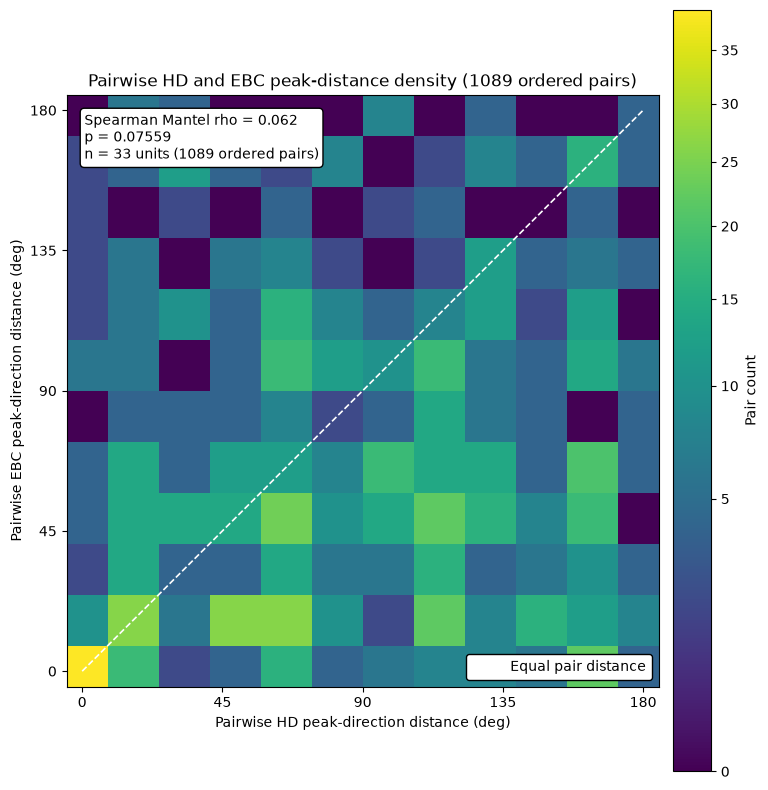

{'same_unit': {'circular_correlation_rho': -0.14642926182571434,
  'permutation_p': 0.41505849415058493,
  'one_to_one_offset_deg': -173.08529316171777,
  'alignment_resultant': 0.12453808693518872,
  'unit_count': 33},
 'pairwise': {'spearman_mantel_rho': 0.06232719109626699,
  'permutation_p': 0.0755924407559244,
  'unit_count': 33,
  'ordered_pair_count': 1089}}

In [11]:
hd_ebc_statistics = analyze_pair("HD", "EBC")
hd_ebc_statistics

## RF–EBC

Each call plots sorted_by and apply_to with the same shared-unit rows, sorted by the sorted_by peak. The two calls explicitly show both sorting directions (four heatmaps). Statistics use RF on x and EBC on y.


----- Based on RF -----


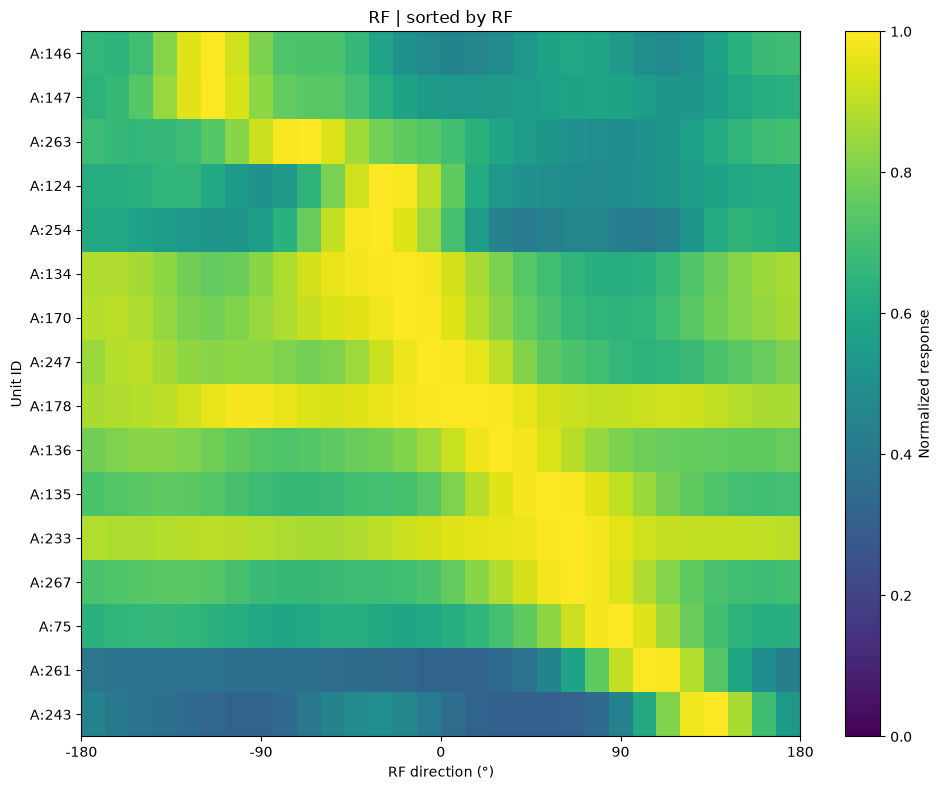

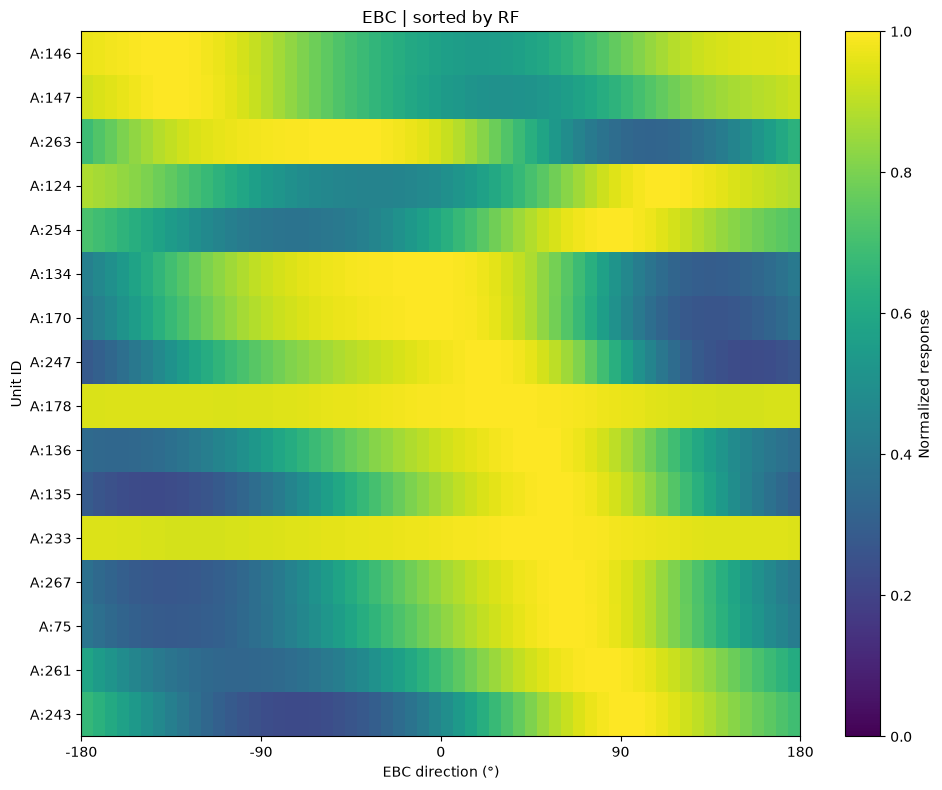

----- Based on EBC -----


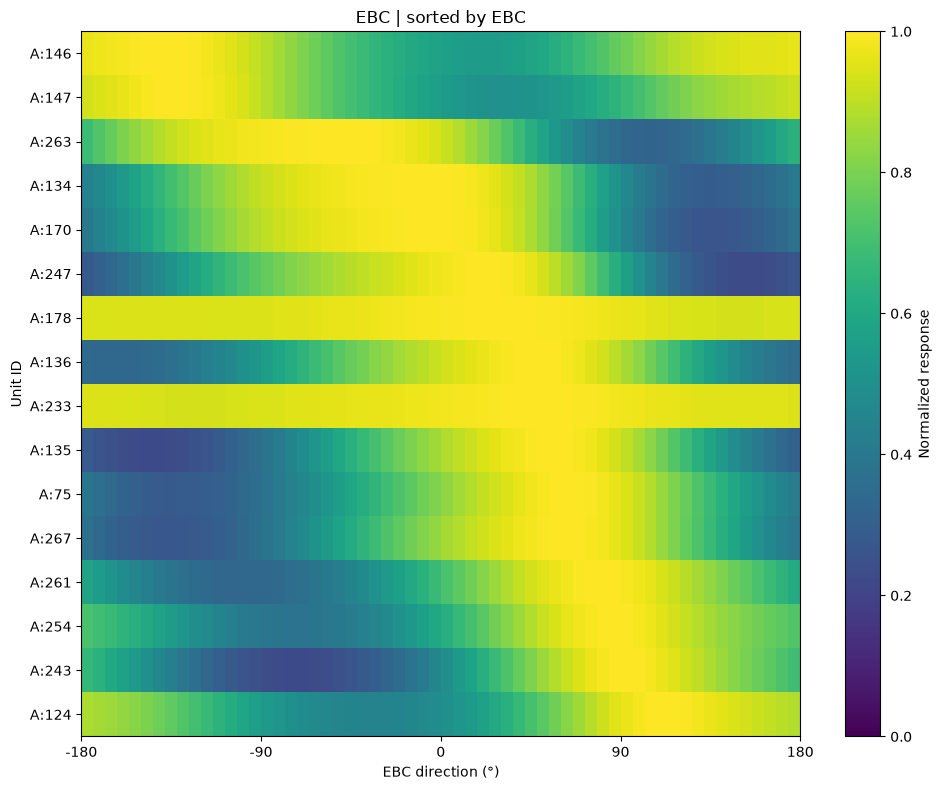

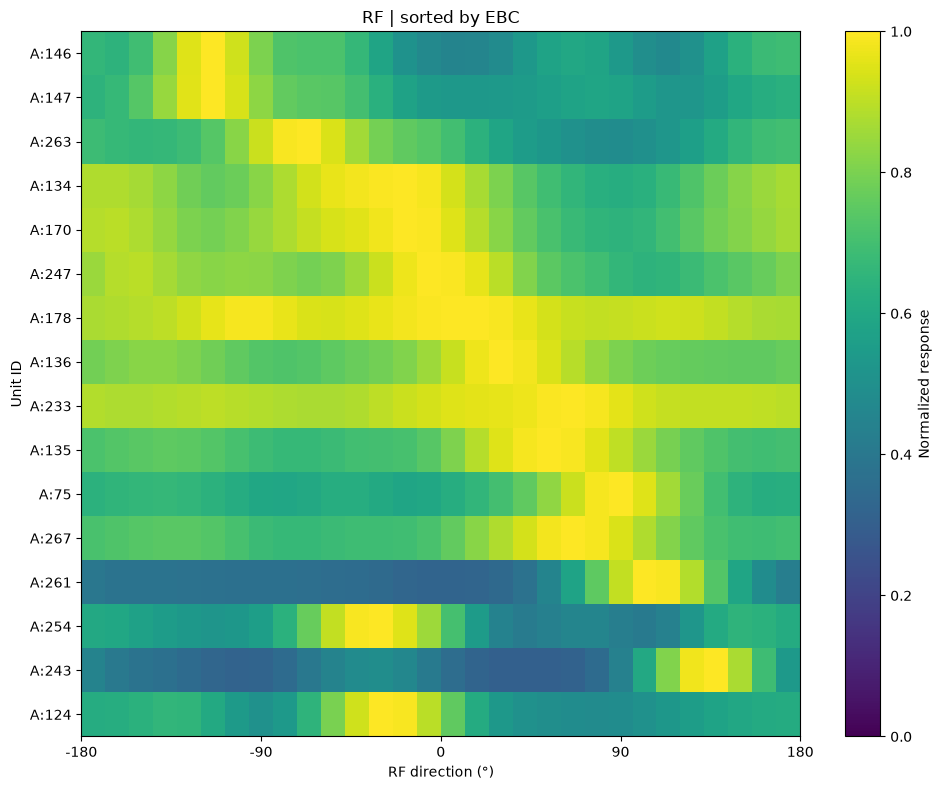

{'order': [('A', 146),
  ('A', 147),
  ('A', 263),
  ('A', 134),
  ('A', 170),
  ('A', 247),
  ('A', 178),
  ('A', 136),
  ('A', 233),
  ('A', 135),
  ('A', 75),
  ('A', 267),
  ('A', 261),
  ('A', 254),
  ('A', 243),
  ('A', 124)],
 'reference_peak_deg': array([-135., -135.,  -45.,   -9.,   -3.,   21.,   33.,   51.,   51.,
          57.,   63.,   63.,   81.,   87.,   93.,  111.]),
 'offset_deg': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'figures': [(<Figure size 1000x800 with 2 Axes>,
   <Axes: title={'center': 'EBC | sorted by EBC'}, xlabel='EBC direction (°)', ylabel='Unit ID'>),
  (<Figure size 1000x800 with 2 Axes>,
   <Axes: title={'center': 'RF | sorted by EBC'}, xlabel='RF direction (°)', ylabel='Unit ID'>)]}

In [12]:
print("----- Based on RF -----")
plot_comparison_heatmaps(sorted_by="RF", apply_to="EBC")
print("----- Based on EBC -----")
plot_comparison_heatmaps(sorted_by="EBC", apply_to="RF")


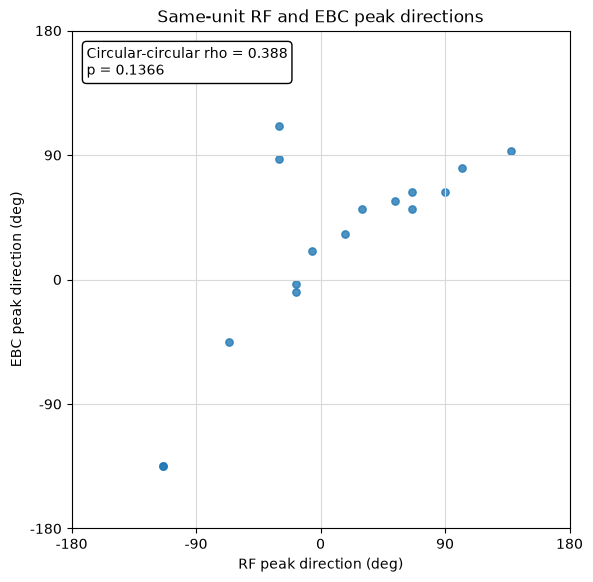

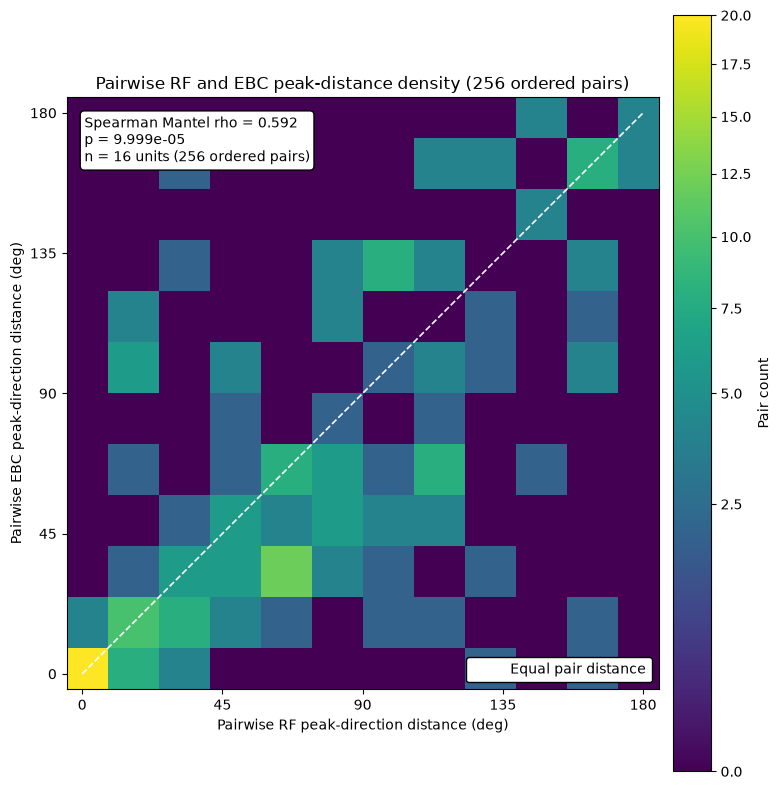

{'same_unit': {'circular_correlation_rho': 0.38766432347911095,
  'permutation_p': 0.13658634136586342,
  'one_to_one_offset_deg': 4.2141667508967275,
  'alignment_resultant': 0.7400389645002611,
  'unit_count': 16},
 'pairwise': {'spearman_mantel_rho': 0.5922226237674899,
  'permutation_p': 9.999000099990002e-05,
  'unit_count': 16,
  'ordered_pair_count': 256}}

In [13]:
rf_ebc_statistics = analyze_pair("RF", "EBC")
rf_ebc_statistics